# Solving for the Electric Field in a Nested Box Capacitor

This notebook solves for the electric potential and electric field for a small metal box held at 100V inside a larger, grounded metal box. We will use the successive over-relaxation (SOR) method to find the potential, and then determine the electric field from the potential.

### Plan:
1.  **Import Libraries and Define Constants:** Import `numpy` and `matplotlib.pyplot`. Define grid size, box dimensions, voltages, and the over-relaxation parameter `ω`.
2.  **Initialize Grid and Boundary Conditions:** Create a 2D grid to represent the potential and set the boundary conditions (inner box at 100V, outer box at 0V).
3.  **Over-Relaxation Algorithm:** Iteratively solve for the potential `V` using the SOR method until the solution converges.
4.  **Calculate Electric Field:** Compute the electric field components `Ex` and `Ey` from the potential using the gradient.
5.  **Visualize Potential:** Plot the potential `V` as a color map and draw equipotential lines.
6.  **Visualize Electric Field:** Plot the electric field lines to see their direction and identify regions of high field strength.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
M = 100        # Grid size (M x M)
V_inner = 100.0  # Voltage of the inner box
omega = 0.9      # Over-relaxation parameter

# --- Box Dimensions ---
# These define the corners of the inner box
inner_box_start = 40
inner_box_end = 60

In [2]:
# --- Initialize Grid ---
V = np.zeros([M+1, M+1], float)

# --- Set Boundary Conditions ---
V[inner_box_start:inner_box_end, inner_box_start:inner_box_end] = V_inner

In [3]:
# --- Over-Relaxation Loop ---
max_iter = 1500
tolerance = 1e-5

for k in range(max_iter):
    delta = 0.0
    for i in range(1, M):
        for j in range(1, M):
            # Skip points inside the inner box
            if i > inner_box_start and i < inner_box_end and j > inner_box_start and j < inner_box_end:
                continue

            old_V = V[i,j]
            new_V = (1 - omega) * old_V + (omega / 4) * (V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1])
            V[i,j] = new_V
            
            # Track the maximum change
            delta = max(delta, abs(new_V - old_V))

    # Check for convergence
    if delta < tolerance:
        print(f"Converged after {k} iterations.")
        break

In [4]:
# --- Calculate Electric Field ---
Ey, Ex = np.gradient(-V)

### JC: although this uses NP.Gradient how you could do it would be using rk45 to approximate it.

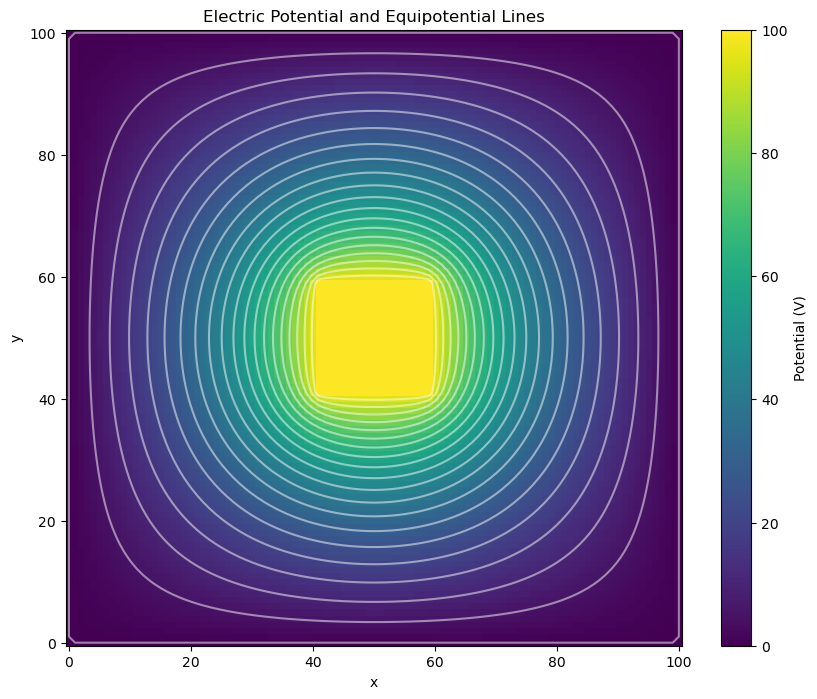

In [7]:
# --- Visualize Potential ---
plt.figure(figsize=(10, 8))
plt.imshow(V, cmap='viridis', origin='lower')
plt.colorbar(label='Potential (V)')
plt.contour(V, levels=20, colors='white', alpha=0.5)
plt.title('Electric Potential and Equipotential Lines')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

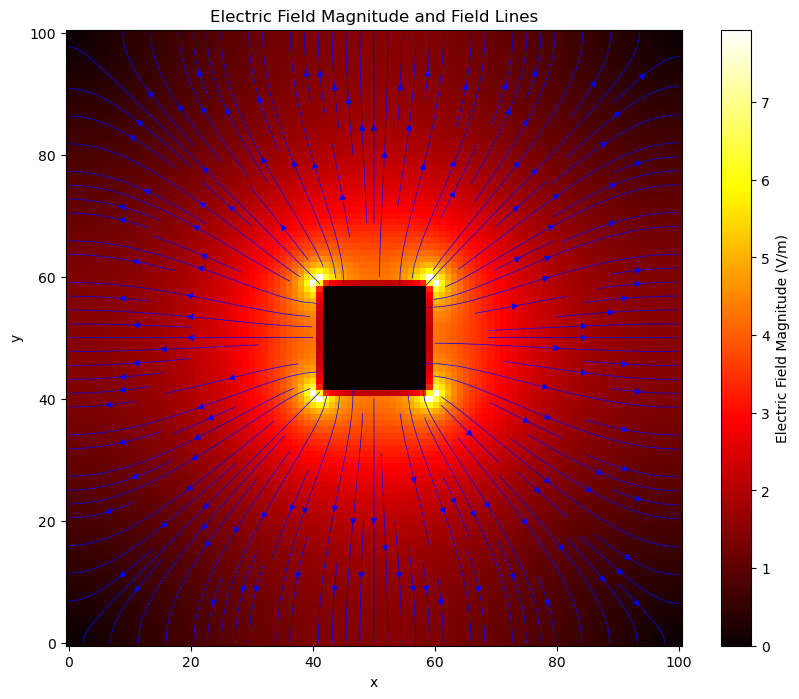

In [8]:
# --- Visualize Electric Field ---
E_magnitude = np.sqrt(Ex**2 + Ey**2)

plt.figure(figsize=(10, 8))
plt.imshow(E_magnitude, cmap='hot', origin='lower')
plt.colorbar(label='Electric Field Magnitude (V/m)')

# Streamplot for field lines
x = np.arange(0, M+1)
y = np.arange(0, M+1)
plt.streamplot(x, y, Ex, Ey, color='blue', linewidth=0.5, density=1.5)

plt.title('Electric Field Magnitude and Field Lines')
plt.xlabel('x')
plt.ylabel('y')
plt.show()